# Testing
### Bevölkerung nach Herkunft und Geschlecht, seit 1901
Beschreibung
Wirtschaftliche Wohnbevölkerung der Stadt Zürich nach Herkunft, Geschlecht und Jahr, seit 1901.

Datum: 14.03.2023


### Importiere die notwendigen Packages

In [43]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [44]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [45]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [46]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [47]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

Definiere Settings. Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen), 

In [48]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [49]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln

In [50]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [51]:
#speichere die variable global, damit ich sie später verwenden kann, wenn ich grafiken mit diesem namen speichere.
package_name = "BEV322OD3222"

In [52]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = "bev_bestand_jahr_herkunft_geschlecht_od3222"
    , dataset_name = "BEV322OD3222"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_herkunft_geschlecht_od3222/download/BEV322OD3222.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_herkunft_geschlecht_od3222 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_herkunft_geschlecht_od3222 

data_source: web


In [53]:
data2betested.head(2)

,StichtagDatJahr,DatenstandCd,HerkunftCd,HerkunftLang,SexCd,SexLang,AnzBestWir
0,1894-01-01,D,1,Schweizer*in,252,unbekannt,89643
1,1894-01-01,D,2,Ausländer*in,252,unbekannt,34768


Berechne weitere Attribute falls notwendig

In [54]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_str = lambda x: x.Jahr.astype(str),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('Jahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr    datetime64[ns]
DatenstandCd               object
HerkunftCd                  int64
HerkunftLang               object
SexCd                       int64
SexLang                    object
AnzBestWir                  int64
Jahr               datetime64[ns]
Jahr_str                   object
Jahr_nbr                    int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [55]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1894 und ein Maximumjahr von 2024


### Einfache Datentests

In [56]:
data2betested.head(2).T

,433,432
StichtagDatJahr,2024-01-01 00:00:00,2024-01-01 00:00:00
DatenstandCd,V,V
HerkunftCd,2,2
HerkunftLang,Ausländer*in,Ausländer*in
SexCd,2,1
SexLang,weiblich,männlich
AnzBestWir,70418,80978
Jahr,2024-01-01 00:00:00,2024-01-01 00:00:00
Jahr_str,2024-01-01,2024-01-01
Jahr_nbr,2024,2024


In [57]:
data2betested.shape

(434, 10)

Beschreibe einzelne Attribute

In [58]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 434 entries, 433 to 0
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   StichtagDatJahr  434 non-null    datetime64[ns]
 1   DatenstandCd     434 non-null    object        
 2   HerkunftCd       434 non-null    int64         
 3   HerkunftLang     434 non-null    object        
 4   SexCd            434 non-null    int64         
 5   SexLang          434 non-null    object        
 6   AnzBestWir       434 non-null    int64         
 7   Jahr             434 non-null    datetime64[ns]
 8   Jahr_str         434 non-null    object        
 9   Jahr_nbr         434 non-null    int32         
dtypes: datetime64[ns](2), int32(1), int64(3), object(4)
memory usage: 146.0 KB


In [59]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 434 rows (observations) and 10 columns (variables).
There seem to be 0 exact duplicates in the data.


Welches sind die Quartiere ohne Werte bei AnzBestWir?

In [60]:
data2betested[np.isnan(data2betested.AnzBestWir)].head()

,StichtagDatJahr,DatenstandCd,HerkunftCd,HerkunftLang,SexCd,SexLang,AnzBestWir,Jahr,Jahr_str,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [61]:
data2betested = data2betested.set_index("Jahr")
data2betested = data2betested.sort_index()

In [62]:
#data2betested.info()
data2betested.index.year.unique()

Index([1894, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908,
       ...
       2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype='int32', name='Jahr', length=126)

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [63]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [64]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,HerkunftCd,SexCd,AnzBestWir,Jahr_nbr
count,434,434,434,434
mean,2,42,"97,050","1,969"
std,1,92,"61,218",34
min,1,1,"9,980","1,894"
25%,1,1,"37,827","1,943"
50%,2,2,"85,310","1,970"
75%,2,2,"150,360","1,997"
max,2,252,"230,254","2,024"


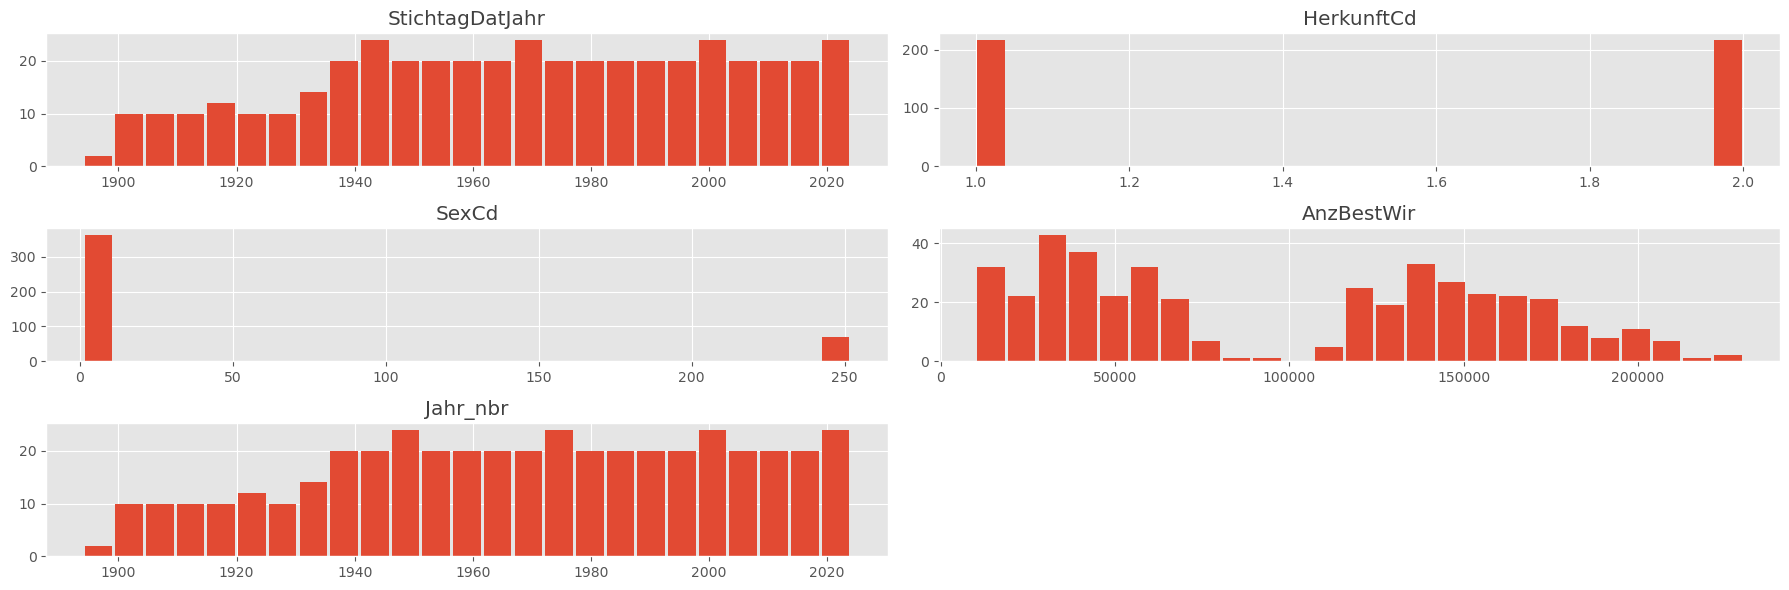

In [65]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [66]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,StichtagDatJahr,DatenstandCd,HerkunftCd,HerkunftLang,SexCd,SexLang,AnzBestWir,Jahr_str,Jahr_nbr
Jahr,,,,,,,,,


### Nullwerte und Missings?

In [67]:
data2betested.isnull().sum()

StichtagDatJahr    0
DatenstandCd       0
HerkunftCd         0
HerkunftLang       0
SexCd              0
SexLang            0
AnzBestWir         0
Jahr_str           0
Jahr_nbr           0
dtype: int64

### Gruppierungen

In [68]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,sum_AnzBestWir
0,2024-01-01,448664
1,2023-01-01,447082
2,2022-01-01,443037


In [69]:
data2betested.columns

Index(['StichtagDatJahr', 'DatenstandCd', 'HerkunftCd', 'HerkunftLang', 'SexCd', 'SexLang',
       'AnzBestWir', 'Jahr_str', 'Jahr_nbr'],
      dtype='object')

In [70]:
agg_Herk = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['HerkunftCd', 'HerkunftLang',]) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('HerkunftCd', ascending=False) 
agg_Herk.reset_index().head(50)

,HerkunftCd,HerkunftLang,sum_AnzBestWir
0,2,Ausländer*in,8740772
1,1,Schweizer*in,33378753


### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [71]:
data2betested.loc[data_max_date].head(2)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)

,StichtagDatJahr,DatenstandCd,HerkunftCd,HerkunftLang,SexCd,SexLang,AnzBestWir,Jahr_str,Jahr_nbr
Jahr,,,,,,,,,
2024-01-01,2024-01-01,V,1,Schweizer*in,1,männlich,144674,2024-01-01,2024
2024-01-01,2024-01-01,V,1,Schweizer*in,2,weiblich,152594,2024-01-01,2024


### Visualisierungen nach Zeitausschnitten

#### Entwicklung Bildungsstand

In [72]:
data2betested.columns

Index(['StichtagDatJahr', 'DatenstandCd', 'HerkunftCd', 'HerkunftLang', 'SexCd', 'SexLang',
       'AnzBestWir', 'Jahr_str', 'Jahr_nbr'],
      dtype='object')

In [73]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr', 'HerkunftCd', 'HerkunftLang',]) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('Jahr', ascending=True) 

myAgg1.reset_index().head(3)

,Jahr,Jahr_nbr,HerkunftCd,HerkunftLang,sum_AnzBestWir
0,1894-01-01,1894,1,Schweizer*in,89643
1,1894-01-01,1894,2,Ausländer*in,34768
2,1900-01-01,1900,1,Schweizer*in,107090


In [74]:
#myAgg1.reset_index().to_excel('//szh.loc/ssz/data/GIS/Sandbox/2024/nzz/test.xlsx', index=False)

In [75]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index()
    , x = 'Jahr:T'
    , y = 'sum_AnzBestWir:Q'
    , myTitle = "Entwicklung der Wohnbevölkerung nach Herkunft, seit "+str(data2betested.index.year.min())
    , x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    , warning_status  = "ignore"
    , category='HerkunftLang:N'
    , category_beschriftung='Herkunft:'
)


In [76]:
grafik1

alt.LayerChart(...)

#### Barcharts mit Seaborn

In [77]:
#help(sns.catplot)     

In [78]:
#Stile for the following sns graphs
sns.set_theme(style="whitegrid")

In [79]:
data2betested.columns

Index(['StichtagDatJahr', 'DatenstandCd', 'HerkunftCd', 'HerkunftLang', 'SexCd', 'SexLang',
       'AnzBestWir', 'Jahr_str', 'Jahr_nbr'],
      dtype='object')

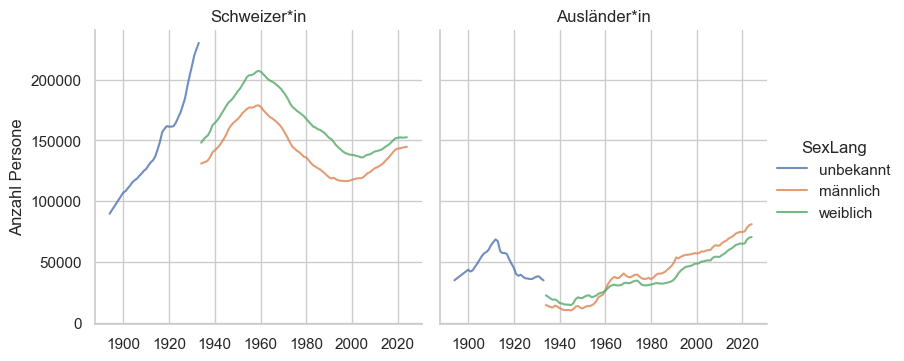

In [80]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = data2betested.reset_index()
    , col = "HerkunftLang"
    , hue = "SexLang"
    , col_wrap = 2
    , height = 3
    , grafiktyp = sns.lineplot
    , x = "Jahr"
    , y = "AnzBestWir"
    , ylabel= "Anzahl Persone"
    )

## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://szhglobal.sharepoint.com/sites/ssz-spo-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=482&e=lj295J)**

---------------------------------------------------------------------------